In [5]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import requests

# !pip install "transformers==4.46.3"
# !pip install "tokenizers==0.20.3"
# !pip install -U sentencepiece

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-small-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-small-handwritten')
model.to('cuda')
print('ready')

Config of the encoder: <class 'transformers.models.deit.modeling_deit.DeiTModel'> is overwritten by shared encoder config: DeiTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 384,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 1536,
  "layer_norm_eps": 1e-12,
  "model_type": "deit",
  "num_attention_heads": 6,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 384,
  "d_model": 256,
  "decoder_attention_heads": 8,
  "decoder_ffn_dim": 1024,
  "decode

ready


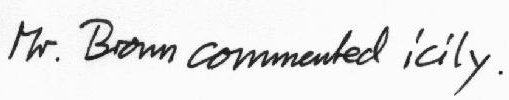

In [9]:
url = "https://huggingface.co/datasets/Xenova/transformers.js-docs/resolve/main/handwriting.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image

In [10]:
url = "https://huggingface.co/datasets/Xenova/transformers.js-docs/resolve/main/handwriting.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

pixel_values = processor(images=image, return_tensors="pt").pixel_values.to('cuda')
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1375: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [11]:
generated_text

'Mr. Brown commented icily .'

### Tuning

In [12]:
import torch

print(isinstance(model, torch.nn.Module))

True


In [ ]:
outputs = model(
    pixel_values=batch["pixel_values"],
    labels=batch["labels"]
)

loss = outputs.loss

loss.backward()
optimizer.step()
optimizer.zero_grad()

In [ ]:
from transformers import Seq2SeqTrainer
from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./trocr",
    per_device_train_batch_size=8,
    learning_rate=5e-5,
    num_train_epochs=5,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

## Dataset [HWR200](https://huggingface.co/datasets/AntiplagiatCompany/HWR200)
Тут в каждой папке `hw_dataset/i` идут картинки их по несколько, отвечающее одному тексту например original1. Все в трех вариациях: Сканы, ФотоСветлое, ФотоТемное.
Разбивки разметки по страницам или по страницам рукописных текстов нету.

In [16]:
# import os

# root = "/mnt/DATA2/seilov/hw_dataset/"

# for path, dirs, files in os.walk(root):
#     print(path, len(files))
#     if len(files):
#         print(files[:5])
#     print()

In [41]:
with open("/mnt/DATA2/seilov/hw_dataset/hw_dataset/1/original1.txt", encoding="utf-8") as f:
    print(f.read()[:1000])

Зачастую под словом «образование» мы понимаем знания, которые помогут нам получить высокооплачиваемую и престижную профессию. Всё реже задумываемся над тем, что же ещё предоставляет оно помимо материальной выгоды… Именно поэтому Игорь Павлович Ботов в своей статье затрагивает проблему необходимости образования нравственного, подчеркивая именно важность правильного воспитания личности в процессе учёбы. Автор обращает наше внимание на то, что образованный, но безнравственный человек будет разлагающе действовать на общество. Ребенок, не усвоивший в школьные годы азы нравственности, вырастет духовно скупым. Именно поэтому так важно учителю вложить в душу ученика всё самое лучшее, и тогда в будущем мы будем меньше сталкиваться с бездушными чиновниками, нечистоплотными политиками и преступниками. Игорь Ботов неравнодушен к поставленной им проблеме, он считает, что термин «образование» и вовсе следует заменить на иной – «воспитание». Я полностью согласна с автором, ведь методы современного об

In [37]:
import json

with open(
    "/mnt/DATA2/seilov/hw_dataset/annotations/Originals/1/original1.json",
    encoding="utf-8"
) as f:
    data = json.load(f)

print(type(data))
print(data.keys() if isinstance(data, dict) else data[:1])

<class 'dict'>
dict_keys(['sentences', 'words_count', 'full_text'])


In [38]:
data['full_text']

'Зачастую под словом «образование» мы понимаем знания, которые помогут нам получить высокооплачиваемую и престижную профессию. Всё реже задумываемся над тем, что же ещё предоставляет оно помимо материальной выгоды… Именно поэтому Игорь Павлович Ботов в своей статье затрагивает проблему необходимости образования нравственного, подчеркивая именно важность правильного воспитания личности в процессе учёбы. Автор обращает наше внимание на то, что образованный, но безнравственный человек будет разлагающе действовать на общество. Ребенок, не усвоивший в школьные годы азы нравственности, вырастет духовно скупым. Именно поэтому так важно учителю вложить в душу ученика всё самое лучшее, и тогда в будущем мы будем меньше сталкиваться с бездушными чиновниками, нечистоплотными политиками и преступниками. Игорь Ботов неравнодушен к поставленной им проблеме, он считает, что термин «образование» и вовсе следует заменить на иной – «воспитание». Я полностью согласна с автором, ведь методы современного о

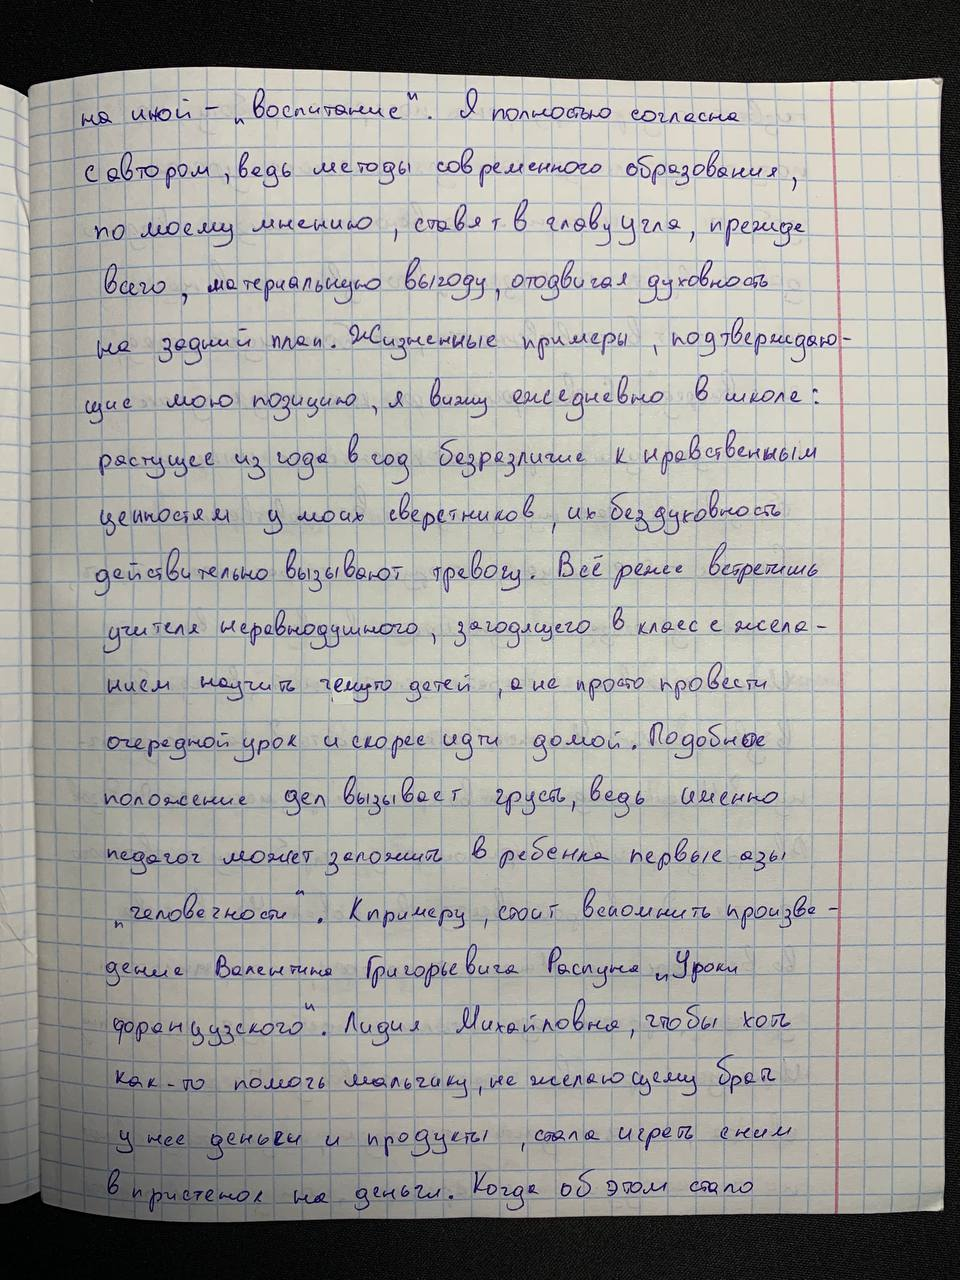

In [40]:
image = Image.open("/mnt/DATA2/seilov/hw_dataset/hw_dataset/1/original1/ФотоСветлое/2.jpg")
image